# 08 · Did the loyalty rollout work? — difference-in-differences (CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The decision.** We launched the loyalty app in some stores, not others. Revenue in
the launch stores went up — but revenue went up *everywhere* (a seasonal tide). Did
the app add anything **net of the tide**, and is it worth rolling out chain-wide?

**Difference-in-differences** subtracts two differences: (treated after − treated
before) − (control after − control before). The shared seasonal move cancels, leaving
the incremental effect — *if* treated and control stores would have moved in parallel
absent the app. We check that pre-trend, estimate the effect with uncertainty, and
turn it into a €/store/week rollout case.

7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 23

## 2 · Simulate a ground truth

40 stores, half get the loyalty app at week 12. Every store shares a seasonal pattern
and has its own baseline level; the app adds a **true €400/store/week**. Treated and
control stores move in **parallel** before launch by construction — so DiD should
recover the €400.


In [2]:
df, true_effect = dgp.did_rollout(n_stores=40, n_weeks=24, launch_week=12, true_effect=400.0, seed=SEED)
print(f"TRUE effect = €{true_effect:.0f} / store / week")
print(f"{df['unit'].nunique()} stores, {df['t'].nunique()} weeks, launch at week 12")
df.head()

TRUE effect = €400 / store / week
40 stores, 24 weeks, launch at week 12


,store,unit,t,week,group,post_treatment,post,revenue
0,store_00,0,0,0,1,False,0,1071.613014
1,store_00,0,1,1,1,False,0,1066.597066
2,store_00,0,2,2,1,False,0,1019.187212
3,store_00,0,3,3,1,False,0,834.246887
4,store_00,0,4,4,1,False,0,1030.278745


## 3 · Identify — the 2×2 estimand and parallel trends

DiD estimates the interaction $\beta_3$ in
$Y = \beta_0 + \beta_1\,\text{group} + \beta_2\,\text{post} + \beta_3(\text{group}\times\text{post}) + \varepsilon$,
which equals
$(\mathbb{E}[Y\mid \text{treat,post}] - \mathbb{E}[Y\mid \text{treat,pre}]) -
(\mathbb{E}[Y\mid \text{ctrl,post}] - \mathbb{E}[Y\mid \text{ctrl,pre}])$.

**Key assumption — parallel trends:** absent the app, treated and control revenue
would have moved in parallel. It's untestable for the post period, but the **pre-period
trends are the evidence** — if they diverge before launch, DiD is not credible (use
synthetic control, notebook 07, instead).


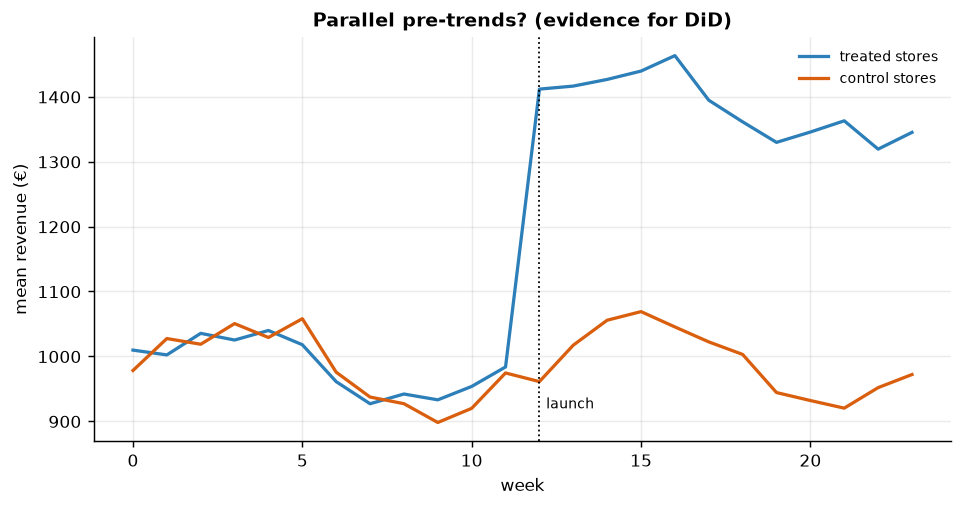

In [3]:
# visual pre-trend check
g = df.groupby(["t", "group"])["revenue"].mean().unstack()
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(g.index, g[1], color=plots.BLUE, lw=1.8, label="treated stores")
ax.plot(g.index, g[0], color=plots.ORANGE, lw=1.8, label="control stores")
ax.axvline(12, color="k", ls=":", lw=1); ax.text(12.2, ax.get_ylim()[0]+50, "launch", fontsize=8)
ax.set_xlabel("week"); ax.set_ylabel("mean revenue (€)"); ax.set_title("Parallel pre-trends? (evidence for DiD)")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()

## 4 · Estimate — Bayesian difference-in-differences

CausalPy's `DifferenceInDifferences` expects the classic **2×2 form** — one pre and
one post observation per unit — so we first collapse each store's weekly revenue to a
pre-launch and a post-launch mean. (The weekly panel above was only for the pre-trend
picture.)


In [4]:
agg = (df.groupby(["unit", "group", "post_treatment"])["revenue"].mean().reset_index())
agg["t"] = agg["post_treatment"].astype(int).astype(float)   # 0 = pre, 1 = post

result = est.did(agg, formula="revenue ~ 1 + group*post_treatment", fast=FAST)
impact = np.asarray(result.causal_impact).ravel()   # posterior of the DiD effect
print(f"DiD estimated effect  €{impact.mean():.0f} / store / week   (true €{true_effect:.0f})")
print(f"90% credible interval [€{np.quantile(impact,0.05):.0f}, €{np.quantile(impact,0.95):.0f}]")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta, y_hat_sigma]


Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


DiD estimated effect  €327 / store / week   (true €400)
90% credible interval [€302, €353]


## 5 · Validate — recover the truth, and the manual 2×2 check

Cross-check the Bayesian estimate against the hand-computed 2×2 difference of means.
Both land near the planted €400; the Bayesian estimate is *mildly shrunk* toward zero
by its regularising priors (a feature, not a bug — it guards against over-reading noisy
effects), while the unregularised 2×2 sits a touch higher. If they disagreed wildly,
that would be the warning sign.


Manual 2×2 DiD          €390
Bayesian DiD (posterior)€327   true €400


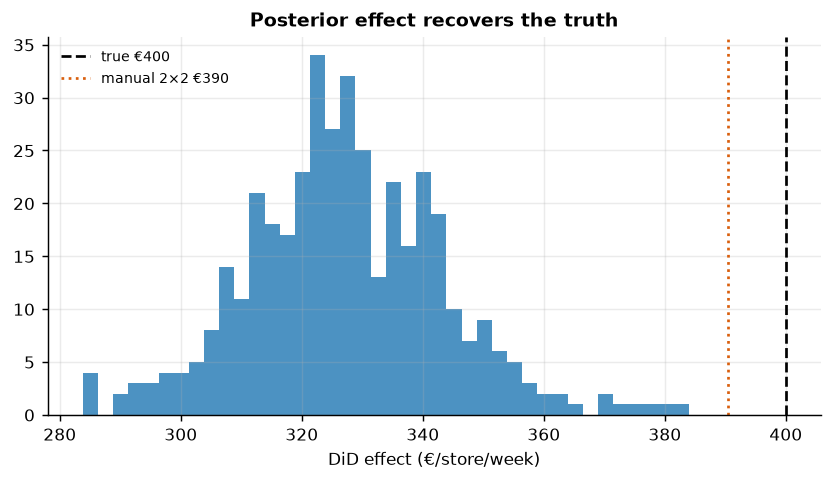

In [5]:
m = df.groupby(["group", "post"])["revenue"].mean()
did_2x2 = (m[1,1] - m[1,0]) - (m[0,1] - m[0,0])
print(f"Manual 2×2 DiD          €{did_2x2:.0f}")
print(f"Bayesian DiD (posterior)€{impact.mean():.0f}   true €{true_effect:.0f}")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.hist(impact, bins=40, color=plots.BLUE, alpha=0.85)
ax.axvline(true_effect, color="k", ls="--", label=f"true €{true_effect:.0f}")
ax.axvline(did_2x2, color=plots.ORANGE, ls=":", label=f"manual 2×2 €{did_2x2:.0f}")
ax.set_xlabel("DiD effect (€/store/week)"); ax.set_title("Posterior effect recovers the truth")
ax.legend(frameon=False, fontsize=8); fig.tight_layout()

## 6 · Decide, in euros — the rollout case

Scale the per-store-week effect to the whole chain and net off the app's running cost.
The decision is **P(chain-wide value > cost)**, not just a positive point estimate.


In [6]:
N_STORES = 500          # chain size for the rollout
WEEKS = 52              # annualised
APP_COST_PER_STORE_WEEK = 120.0   # € running cost of the app per store per week

net_per_store_week = impact - APP_COST_PER_STORE_WEEK
annual_value = net_per_store_week * N_STORES * WEEKS
p_worth = (net_per_store_week > 0).mean()
print(f"Net effect per store/week   €{net_per_store_week.mean():.0f}  (effect − €{APP_COST_PER_STORE_WEEK:.0f} cost)")
print(f"Projected annual value       €{annual_value.mean():,.0f}  "
      f"[90% €{np.quantile(annual_value,0.05):,.0f}, €{np.quantile(annual_value,0.95):,.0f}]")
print(f"P(app pays for itself)       {p_worth:.2f}  → " + ("ROLL OUT" if p_worth > 0.9 else "pilot further"))

Net effect per store/week   €207  (effect − €120 cost)
Projected annual value       €5,389,807  [90% €4,728,804, €6,069,367]
P(app pays for itself)       1.00  → ROLL OUT


## 7 · Caveats

- **Parallel trends is the whole ballgame** — and it's untestable for the post period.
  Pre-trends that visibly diverge kill the design; use synthetic control instead.
- **Staggered adoption trap.** If stores adopt at *different* times, naive two-way
  fixed-effects DiD uses already-treated stores as controls ("forbidden comparisons")
  and can put **negative weights** on some effects (Goodman-Bacon). For staggered
  rollouts use modern estimators (Callaway–Sant'Anna, Sun–Abraham).
- **No spillover.** If control stores are near treated ones and customers cross over,
  the control is contaminated and the effect is understated.
- **Composition shifts.** If the treated and control store mix changes over the window
  (closures, openings), the "difference of differences" mixes effect with composition.
